# Notebook 02 — Minimum Edit Distance

**Project:** SciSpell — a domain-aware spelling correction system for scientific text
**Stage:** Measuring how far a typed string is from a real word

---

## The problem this solves

Notebook 01 built a dictionary that can answer one question: *does this string
exist in English?* When the answer is no, we know the user made an error — but we
still have no idea what they meant. `recieve` is not in the dictionary; neither is
`xqzptl`. The first has an obvious intended word, the second does not, and nothing
in a membership test can tell them apart.

What separates them is **distance**. `recieve` is two small keystroke slips away
from *receive*; `xqzptl` is far from everything. To turn detection into
correction, we need a way to measure that distance numerically.

## Minimum edit distance

**Minimum edit distance** is the smallest number of single-character operations
needed to transform one string into another. The classic operation set —
**Levenshtein distance** — allows three:

| Operation | Example | Cost |
|---|---|---|
| **Insertion** | `recieve` → `recieive` | 1 |
| **Deletion** | `recieve` → `recieve` minus a letter | 1 |
| **Substitution** | `recieve` → `receive` (swap one letter) | 1 |

Transforming `kitten` into `sitting` takes three operations, so their edit
distance is 3.

The word *minimum* carries the weight: many sequences of edits can turn one string
into another, and we want the cheapest. That makes this an optimisation problem,
and computing it naively — trying every possible sequence — is exponentially
expensive.

## Why dynamic programming

Edit distance has a property that rescues it: the cheapest way to align two full
strings is built from the cheapest ways to align their **prefixes**. Knowing the
best alignment of `rec` and `rece` helps compute the best alignment of `reci` and
`recei`, and so on.

**Dynamic programming** exploits this by filling a table where each cell holds the
edit distance between one prefix of the first string and one prefix of the second.
Every cell is computed once, from its neighbours, and reused. The cost drops from
exponential to **O(m × n)** — the product of the two string lengths.

## What this notebook builds

1. **Levenshtein distance** implemented from first principles, with the full
   dynamic programming table exposed rather than hidden.
2. **Backtrace and alignment** — recovering *which* edits were made, not just how
   many, which later explains corrections to the user.
3. **A visualisation** of the DP table showing the optimal path through it.
4. **Damerau–Levenshtein** — adding **transposition** (`teh` → `the` as one
   operation, not two), because adjacent-letter swaps are among the most common
   real typing errors.
5. **Weighted edit distance** — recognising that not all errors are equally
   likely. Substituting `e` for `r` (adjacent keys) is more plausible than `e`
   for `p`. These weights become the foundation of the **noisy channel model**
   in Notebook 04, where distance stops being a count and becomes a probability.

In [1]:
# ── Setup — reload artefacts from Notebook 01 ─────────────────────
import re
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Tokenizer — identical rules to Notebook 01, reused everywhere in this project
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text: str) -> list[str]:
    """Lowercase the text and return alphabetic tokens (internal apostrophes kept)."""
    return TOKEN_RE.findall(text.lower())

# Artefacts
word_freq  = json.loads((DATA_DIR / "word_freq.json").read_text(encoding="utf-8"))
DICTIONARY = set((DATA_DIR / "dictionary.txt").read_text(encoding="utf-8").split("\n"))
metadata   = json.loads((DATA_DIR / "corpus_metadata.json").read_text(encoding="utf-8"))

print(f"Dictionary       : {len(DICTIONARY):,} words")
print(f"Domain frequencies: {len(word_freq):,} types "
      f"({sum(word_freq.values()):,} tokens)")
print(f"Corpus           : {', '.join(b['author'].split()[-1] for b in metadata['books'])}")
print(f"Zipf α (mid-range): {metadata['zipf']['alpha_midrange']}")

Dictionary       : 369,989 words
Domain frequencies: 8,895 types (229,325 tokens)
Corpus           : Darwin, Einstein, Faraday
Zipf α (mid-range): 1.0


## 2. Levenshtein distance from first principles

### The table

To compute the distance between a **source** string (what the user typed, length
*m*) and a **target** string (a dictionary word, length *n*), we fill an
(m+1) × (n+1) table `D`, where:

> `D[i][j]` = the edit distance between the **first i letters** of the source
> and the **first j letters** of the target.

Row 0 and column 0 are the base cases — transforming from or to the empty string:

- `D[i][0] = i`  (delete all i letters)
- `D[0][j] = j`  (insert all j letters)

### The recurrence

Every other cell looks at just three neighbours, each representing one operation:

    D[i][j] = min(
        D[i-1][j]   + 1,          ← deletion    (drop source letter i)
        D[i][j-1]   + 1,          ← insertion   (add target letter j)
        D[i-1][j-1] + cost        ← substitution, where
    )                                cost = 0 if the letters already match
                                     cost = 1 if they differ

The bottom-right cell `D[m][n]` is the answer: the minimum edit distance between
the complete strings. Filling m × n cells, each in constant time, gives the
**O(m × n)** complexity promised earlier.

In [2]:
# ── Levenshtein distance with the full DP table ───────────────────
def levenshtein_matrix(source: str, target: str) -> tuple[int, np.ndarray]:
    """Edit distance between source and target, plus the full DP table."""
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1), dtype=int)
    D[:, 0] = np.arange(m + 1)          # base case: deletions down column 0
    D[0, :] = np.arange(n + 1)          # base case: insertions along row 0

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if source[i - 1] == target[j - 1] else 1
            D[i, j] = min(D[i - 1, j] + 1,          # deletion
                          D[i, j - 1] + 1,          # insertion
                          D[i - 1, j - 1] + cost)   # substitution / match
    return int(D[m, n]), D

def levenshtein(source: str, target: str) -> int:
    return levenshtein_matrix(source, target)[0]

def show_matrix(source: str, target: str) -> None:
    dist, D = levenshtein_matrix(source, target)
    header = "      ε  " + "  ".join(target)
    print(header)
    for i, row in enumerate(D):
        label = "ε" if i == 0 else source[i - 1]
        print(f"  {label}  " + " ".join(f"{v:2d}" for v in row))
    print(f"\n  distance('{source}', '{target}') = {dist}")

# The textbook example, verified against its known answer of 3
show_matrix("kitten", "sitting")

print("\nQuick checks:")
cases = [("recieve", "receive"), ("teh", "the"), ("acress", "across"),
         ("same", "same"), ("", "abc"), ("xqzptl", "receive")]
for s, t in cases:
    print(f"  distance({s!r:>10}, {t!r:>10}) = {levenshtein(s, t)}")

      ε  s  i  t  t  i  n  g
  ε   0  1  2  3  4  5  6  7
  k   1  1  2  3  4  5  6  7
  i   2  2  1  2  3  4  5  6
  t   3  3  2  1  2  3  4  5
  t   4  4  3  2  1  2  3  4
  e   5  5  4  3  2  2  3  4
  n   6  6  5  4  3  3  2  3

  distance('kitten', 'sitting') = 3

Quick checks:
  distance( 'recieve',  'receive') = 2
  distance(     'teh',      'the') = 2
  distance(  'acress',   'across') = 1
  distance(    'same',     'same') = 0
  distance(        '',      'abc') = 3
  distance(  'xqzptl',  'receive') = 7


## 3. Backtrace: recovering the edits themselves

The distance says *how many* edits — but a correction system should also know
*which* edits, for two reasons:

1. **Explainability** — the app can show the user "recieve → receive: transposed
   *ie* → *ei*" rather than a bare suggestion.
2. **The noisy channel** (Notebook 04) — estimating P(typo | word) requires
   knowing which specific operation occurred, because some slips are far more
   common than others.

The DP table already contains this information. Every cell's value came from one
of its three neighbours; starting at the bottom-right corner and repeatedly asking
*"which neighbour produced this value?"* walks the **optimal path** back to the
origin. Each step of that walk is one edit:

| Step in table | Meaning |
|---|---|
| Diagonal, letters equal | match (no edit) |
| Diagonal, letters differ | substitution |
| Up | deletion of a source letter |
| Left | insertion of a target letter |

Ties are possible — several optimal paths can exist — and we resolve them with a
fixed preference (diagonal first), which keeps output deterministic.

In [3]:
# ── Backtrace — recover the optimal edit sequence ─────────────────
def backtrace(source: str, target: str) -> list[tuple[str, str, str]]:
    """Walk the DP table backwards; return edits as (operation, from, to)."""
    _, D = levenshtein_matrix(source, target)
    i, j = len(source), len(target)
    ops = []
    while i > 0 or j > 0:
        s_ch = source[i - 1] if i > 0 else ""
        t_ch = target[j - 1] if j > 0 else ""
        if i > 0 and j > 0 and D[i, j] == D[i - 1, j - 1] + (s_ch != t_ch):
            ops.append(("match" if s_ch == t_ch else "substitute", s_ch, t_ch))
            i, j = i - 1, j - 1
        elif i > 0 and D[i, j] == D[i - 1, j] + 1:
            ops.append(("delete", s_ch, ""))
            i -= 1
        else:
            ops.append(("insert", "", t_ch))
            j -= 1
    return ops[::-1]                      # walked backwards → reverse to read forwards

def show_alignment(source: str, target: str) -> None:
    ops = backtrace(source, target)
    top    = " ".join(s if s else "·" for _, s, _ in ops)
    bottom = " ".join(t if t else "·" for _, _, t in ops)
    marks  = " ".join({"match": "|", "substitute": "x",
                       "delete": "-", "insert": "+"}[op] for op, _, _ in ops)
    edits  = [f"{op} {s!r}→{t!r}" if op == "substitute"
              else f"{op} {s!r}" if op == "delete"
              else f"{op} {t!r}" if op == "insert" else None
              for op, s, t in ops]
    print(f"{source} → {target}")
    print(f"   {top}\n   {marks}\n   {bottom}")
    print("   edits:", ", ".join(e for e in edits if e) or "none")
    print()

for s, t in [("kitten", "sitting"), ("recieve", "receive"),
             ("teh", "the"), ("acress", "across")]:
    show_alignment(s, t)

kitten → sitting
   k i t t e n ·
   x | | | x | +
   s i t t i n g
   edits: substitute 'k'→'s', substitute 'e'→'i', insert 'g'

recieve → receive
   r e c i e v e
   | | | x x | |
   r e c e i v e
   edits: substitute 'i'→'e', substitute 'e'→'i'

teh → the
   t e h
   | x x
   t h e
   edits: substitute 'e'→'h', substitute 'h'→'e'

acress → across
   a c r e s s
   | | | x | |
   a c r o s s
   edits: substitute 'e'→'o'



## 4. Visualising the table and the optimal path

The backtrace is a path through the matrix: starting at the bottom-right corner,
each step moves to the neighbour that produced the current cell's value. Plotting
the table as a heat map with that path overlaid shows the algorithm's "reasoning"
in one image:

- **Diagonal runs** are stretches where the strings agree — free progress.
- **Kinks** (a step down, right, or a costly diagonal) are the actual edits.
- The colour gradient shows accumulated cost flowing from top-left (0) to the
  final distance at bottom-right.

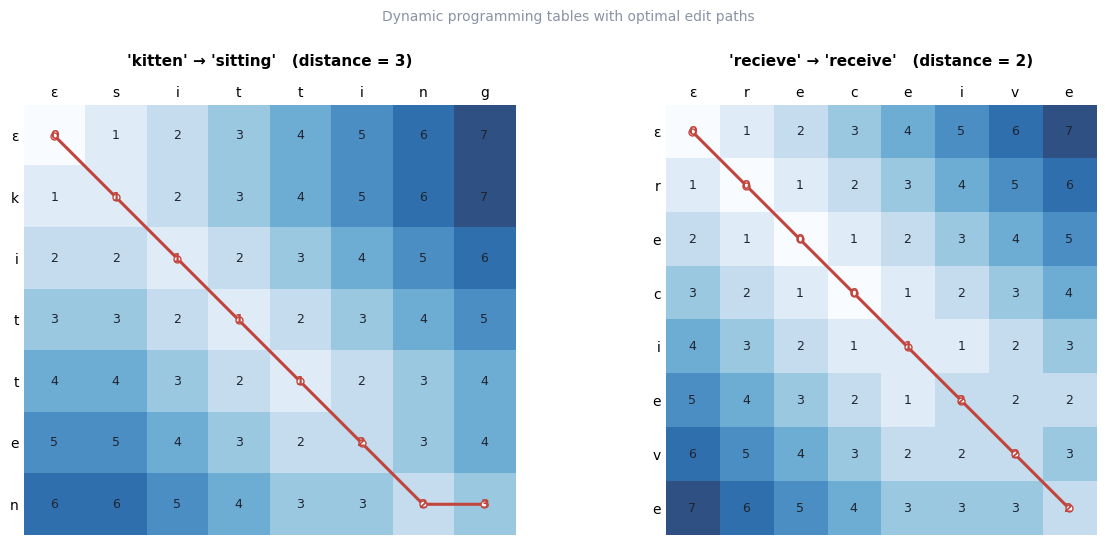

Figure saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/figures/edit_distance_tables.png


In [4]:
# ── DP table heat map with the optimal path ───────────────────────
def plot_dp_table(source: str, target: str, ax) -> None:
    dist, D = levenshtein_matrix(source, target)

    # Recover path cells by re-walking the table (same logic as backtrace)
    i, j = len(source), len(target)
    path = [(i, j)]
    while i > 0 or j > 0:
        s_ch = source[i - 1] if i > 0 else ""
        t_ch = target[j - 1] if j > 0 else ""
        if i > 0 and j > 0 and D[i, j] == D[i - 1, j - 1] + (s_ch != t_ch):
            i, j = i - 1, j - 1
        elif i > 0 and D[i, j] == D[i - 1, j] + 1:
            i -= 1
        else:
            j -= 1
        path.append((i, j))

    ax.imshow(D, cmap="Blues", alpha=0.85)
    pr, pc = zip(*path)
    ax.plot(pc, pr, color="#c2453d", lw=2.2, marker="o", ms=5,
            mfc="white", mec="#c2453d", zorder=3)

    for r in range(D.shape[0]):
        for c in range(D.shape[1]):
            on_path = (r, c) in path
            ax.text(c, r, D[r, c], ha="center", va="center", fontsize=9,
                    weight="bold" if on_path else "normal",
                    color="#c2453d" if on_path else "#1f2430")

    ax.set_xticks(range(len(target) + 1), ["ε"] + list(target), fontsize=10)
    ax.set_yticks(range(len(source) + 1), ["ε"] + list(source), fontsize=10)
    ax.xaxis.set_ticks_position("top")
    ax.set_title(f"'{source}' → '{target}'   (distance = {dist})",
                 fontsize=11, weight="bold", pad=28)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
plot_dp_table("kitten", "sitting", axes[0])
plot_dp_table("recieve", "receive", axes[1])
fig.suptitle("Dynamic programming tables with optimal edit paths",
             fontsize=10, color="#8a93a5", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "edit_distance_tables.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved → {FIG_DIR / 'edit_distance_tables.png'}")

## 5. Damerau–Levenshtein: charging swaps fairly

The alignments showed the flaw: `teh → the` and `recieve → receive` are each a
single physical action — two adjacent letters typed in the wrong order — yet
Levenshtein charges 2. This matters because empirical studies of typing errors
(Damerau, 1964) found that four operation types — insertion, deletion,
substitution, and **transposition of adjacent letters** — account for the vast
majority of human misspellings. A distance metric that overprices one of the four
will under-rank the very corrections users most often need.

**Damerau–Levenshtein distance** adds transposition as a first-class operation of
cost 1. One extra case joins the recurrence: if the current source letter equals
the *previous* target letter and vice versa (the swap pattern `xy` ↔ `yx`), the
cell may also be reached from `D[i-2][j-2] + 1`:

    if source[i-1] == target[j-2] and source[i-2] == target[j-1]:
        D[i][j] = min(D[i][j], D[i-2][j-2] + 1)

(Strictly, this variant is called *optimal string alignment*: each letter pair
may be transposed once, which is exactly the typing-slip case we care about.)

> Damerau, F. J. (1964). A technique for computer detection and correction of
> spelling errors. *Communications of the ACM*, 7(3), 171–176.

With this in place, the distance-1 neighbourhood of a typo now contains the swap
corrections — `teh` sits next to `the`, `recieve` next to `receive` — which is
where Notebook 04's candidate generator will look first.

In [5]:
# ── Damerau–Levenshtein (optimal string alignment) ───────────────
def damerau_levenshtein(source: str, target: str) -> int:
    """Edit distance with insertion, deletion, substitution, and adjacent transposition."""
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1), dtype=int)
    D[:, 0] = np.arange(m + 1)
    D[0, :] = np.arange(n + 1)

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if source[i - 1] == target[j - 1] else 1
            D[i, j] = min(D[i - 1, j] + 1,            # deletion
                          D[i, j - 1] + 1,            # insertion
                          D[i - 1, j - 1] + cost)     # substitution / match
            if (i > 1 and j > 1
                    and source[i - 1] == target[j - 2]
                    and source[i - 2] == target[j - 1]):
                D[i, j] = min(D[i, j], D[i - 2, j - 2] + 1)   # transposition
    return int(D[m, n])

print(f"{'pair':<28}{'Levenshtein':>12}{'Damerau':>10}")
print("─" * 50)
cases = [("teh", "the"), ("recieve", "receive"), ("hte", "the"),
         ("acress", "across"), ("kitten", "sitting"),
         ("abcd", "badc"), ("xqzptl", "receive")]
for s, t in cases:
    lev, dam = levenshtein(s, t), damerau_levenshtein(s, t)
    marker = "  ← swap rerated" if dam < lev else ""
    print(f"{s + ' → ' + t:<28}{lev:>12}{dam:>10}{marker}")

pair                         Levenshtein   Damerau
──────────────────────────────────────────────────
teh → the                              2         1  ← swap rerated
recieve → receive                      2         1  ← swap rerated
hte → the                              2         1  ← swap rerated
acress → across                        1         1
kitten → sitting                       3         3
abcd → badc                            3         2  ← swap rerated
xqzptl → receive                       7         7


## 6. Weighted edit distance: not all errors are equally likely

Damerau–Levenshtein treats every substitution as cost 1 — substituting *e*→*r*
costs the same as *e*→*p*. But a glance at a QWERTY keyboard says otherwise:
*e* and *r* are neighbours, so a slipped finger produces one far more often than
the other. The same holds for the other operations: some slips are simply more
probable than others.

**Weighted edit distance** replaces the flat cost of 1 with operation-specific
costs. Ours are keyboard-geometry based:

| Operation | Cost | Rationale |
|---|---|---|
| Substitution, adjacent keys | 0.6 | The classic fat-finger slip |
| Substitution, non-adjacent | 1.0 | Requires a different explanation |
| Insertion / deletion | 0.9 | Common, roughly uniform slips |
| Adjacent transposition | 0.7 | Very common ordering slip |

The exact values are design parameters, not measurements — what matters is the
*ordering* (adjacent-substitution < transposition < insert/delete 
far-substitution), which lets distance **rank** candidates rather than merely
count edits: `jat` is now closer to *hat* (adjacent *j/h*) than to *cat*
(non-adjacent *j/c*), though both are one edit away.

### Where this is heading

A weighted distance is a stepping stone. The principled version of "some errors
are likelier than others" is the **noisy channel model** (Notebook 04): score a
candidate correction *w* for typed string *x* by

    P(w | x)  ∝  P(x | w) · P(w)

where P(x|w) is the **error model** — the probability of this particular slip —
and P(w) is the **language model** from our corpus frequencies. Weighted costs
are effectively negative log-probabilities of errors; today's geometry weights
become tomorrow's probability estimates.

In [6]:
# ── Weighted edit distance using QWERTY keyboard geometry ────────
KEYBOARD_ROWS = ["qwertyuiop", "asdfghjkl", "zxcvbnm"]

def build_adjacency() -> dict[str, set[str]]:
    """Map each letter to the set of letters physically adjacent on QWERTY."""
    pos = {ch: (r, c) for r, row in enumerate(KEYBOARD_ROWS)
                      for c, ch in enumerate(row)}
    adj = {ch: set() for ch in pos}
    for a, (ra, ca) in pos.items():
        for b, (rb, cb) in pos.items():
            if a != b and abs(ra - rb) <= 1 and abs(ca - cb) <= 1:
                adj[a].add(b)
    return adj

KEY_ADJ = build_adjacency()

COST_SUB_ADJACENT = 0.6
COST_SUB_FAR      = 1.0
COST_INS_DEL      = 0.9
COST_TRANSPOSE    = 0.7

def weighted_edit_distance(source: str, target: str) -> float:
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1))
    D[:, 0] = np.arange(m + 1) * COST_INS_DEL
    D[0, :] = np.arange(n + 1) * COST_INS_DEL

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s_ch, t_ch = source[i - 1], target[j - 1]
            if s_ch == t_ch:
                sub = 0.0
            elif t_ch in KEY_ADJ.get(s_ch, set()):
                sub = COST_SUB_ADJACENT
            else:
                sub = COST_SUB_FAR
            D[i, j] = min(D[i - 1, j] + COST_INS_DEL,
                          D[i, j - 1] + COST_INS_DEL,
                          D[i - 1, j - 1] + sub)
            if (i > 1 and j > 1 and s_ch == target[j - 2]
                    and source[i - 2] == t_ch):
                D[i, j] = min(D[i, j], D[i - 2, j - 2] + COST_TRANSPOSE)
    return float(D[m, n])

print("Ranking power — same unweighted distance, different weighted cost:")
print(f"{'pair':<22}{'Damerau':>8}{'weighted':>10}")
print("─" * 40)
for s, t in [("jat", "hat"), ("jat", "cat"), ("jat", "rat"),
             ("teh", "the"), ("tge", "the"), ("tpe", "the")]:
    print(f"{s + ' → ' + t:<22}{damerau_levenshtein(s, t):>8}"
          f"{weighted_edit_distance(s, t):>10.2f}")

Ranking power — same unweighted distance, different weighted cost:
pair                   Damerau  weighted
────────────────────────────────────────
jat → hat                    1      0.60
jat → cat                    1      1.00
jat → rat                    1      1.00
teh → the                    1      0.70
tge → the                    1      0.60
tpe → the                    1      1.00


## 7. Exporting the distance module

Notebooks are excellent for developing and explaining algorithms, but poor
containers for shared code: the correction engine (Notebook 04), the evaluation
(Notebook 05), and the application all need these functions, and each keeping its
own copy would let the versions drift apart.

We therefore export the finished functions to **`app/edit_distance.py`** — a
plain Python module, written from this notebook so the notebook remains the
single source of truth. The cell below writes the module, imports it back, and
asserts that the imported functions reproduce this notebook's results exactly —
the same round-trip discipline used for Notebook 01's artefacts.

In [7]:
# ── Cell 14: Write app/edit_distance.py, re-import, verify ────────────────
APP_DIR = PROJECT_ROOT / "app"
APP_DIR.mkdir(exist_ok=True)
MODULE_PATH = APP_DIR / "edit_distance.py"

MODULE_SOURCE = '''"""
Edit distance module for SciSpell.
Developed and documented in notebooks/02_Edit_Distance.ipynb — that notebook is
the source of truth; edit there and re-export.
"""
import re
import numpy as np

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    """Lowercase the text and return alphabetic tokens (internal apostrophes kept)."""
    return TOKEN_RE.findall(text.lower())

KEYBOARD_ROWS = ["qwertyuiop", "asdfghjkl", "zxcvbnm"]

def _build_adjacency():
    pos = {ch: (r, c) for r, row in enumerate(KEYBOARD_ROWS)
                      for c, ch in enumerate(row)}
    adj = {ch: set() for ch in pos}
    for a, (ra, ca) in pos.items():
        for b, (rb, cb) in pos.items():
            if a != b and abs(ra - rb) <= 1 and abs(ca - cb) <= 1:
                adj[a].add(b)
    return adj

KEY_ADJ = _build_adjacency()

COST_SUB_ADJACENT = 0.6
COST_SUB_FAR      = 1.0
COST_INS_DEL      = 0.9
COST_TRANSPOSE    = 0.7

def levenshtein(source, target):
    """Classic edit distance: insertion, deletion, substitution, all cost 1."""
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1), dtype=int)
    D[:, 0] = np.arange(m + 1)
    D[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if source[i - 1] == target[j - 1] else 1
            D[i, j] = min(D[i - 1, j] + 1, D[i, j - 1] + 1,
                          D[i - 1, j - 1] + cost)
    return int(D[m, n])

def damerau_levenshtein(source, target):
    """Edit distance with adjacent transposition as a fourth unit-cost operation."""
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1), dtype=int)
    D[:, 0] = np.arange(m + 1)
    D[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if source[i - 1] == target[j - 1] else 1
            D[i, j] = min(D[i - 1, j] + 1, D[i, j - 1] + 1,
                          D[i - 1, j - 1] + cost)
            if (i > 1 and j > 1 and source[i - 1] == target[j - 2]
                    and source[i - 2] == target[j - 1]):
                D[i, j] = min(D[i, j], D[i - 2, j - 2] + 1)
    return int(D[m, n])

def weighted_edit_distance(source, target):
    """QWERTY-weighted Damerau distance; lower = more plausible typing slip."""
    m, n = len(source), len(target)
    D = np.zeros((m + 1, n + 1))
    D[:, 0] = np.arange(m + 1) * COST_INS_DEL
    D[0, :] = np.arange(n + 1) * COST_INS_DEL
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s_ch, t_ch = source[i - 1], target[j - 1]
            if s_ch == t_ch:
                sub = 0.0
            elif t_ch in KEY_ADJ.get(s_ch, set()):
                sub = COST_SUB_ADJACENT
            else:
                sub = COST_SUB_FAR
            D[i, j] = min(D[i - 1, j] + COST_INS_DEL,
                          D[i, j - 1] + COST_INS_DEL,
                          D[i - 1, j - 1] + sub)
            if (i > 1 and j > 1 and s_ch == target[j - 2]
                    and source[i - 2] == t_ch):
                D[i, j] = min(D[i, j], D[i - 2, j - 2] + COST_TRANSPOSE)
    return float(D[m, n])
'''

MODULE_PATH.write_text(MODULE_SOURCE, encoding="utf-8")

# ── Re-import and verify against the notebook's own implementations ──
import importlib, sys
sys.path.insert(0, str(APP_DIR))
import edit_distance as ed
importlib.reload(ed)

test_pairs = [("kitten", "sitting"), ("recieve", "receive"), ("teh", "the"),
              ("hte", "the"), ("acress", "across"), ("abcd", "badc"),
              ("jat", "hat"), ("jat", "cat"), ("tge", "the"), ("tpe", "the"),
              ("same", "same"), ("", "abc"), ("xqzptl", "receive")]

checks = [
    ("Module file written", MODULE_PATH.exists(), MODULE_PATH.name),
    ("Levenshtein matches notebook",
     all(ed.levenshtein(s, t) == levenshtein(s, t) for s, t in test_pairs),
     f"{len(test_pairs)} pairs"),
    ("Damerau matches notebook",
     all(ed.damerau_levenshtein(s, t) == damerau_levenshtein(s, t) for s, t in test_pairs),
     f"{len(test_pairs)} pairs"),
    ("Weighted matches notebook",
     all(abs(ed.weighted_edit_distance(s, t) - weighted_edit_distance(s, t)) < 1e-9
         for s, t in test_pairs),
     f"{len(test_pairs)} pairs"),
    ("Tokenizer identical to Notebook 01",
     ed.TOKEN_RE.pattern == TOKEN_RE.pattern, "same regex"),
    ("Textbook value reproduced", ed.levenshtein("kitten", "sitting") == 3, "= 3"),
    ("Swap discount active", ed.damerau_levenshtein("teh", "the") == 1, "teh→the = 1"),
    ("Keyboard weighting active",
     ed.weighted_edit_distance("jat", "hat") < ed.weighted_edit_distance("jat", "cat"),
     "hat < cat"),
]

width = max(len(c[0]) for c in checks)
print("VERIFICATION\n" + "─" * (width + 26))
for label, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label:<{width}}  {detail}")
print("─" * (width + 26))
print(f"  {sum(ok for _, ok, _ in checks)}/{len(checks)} checks passed")
assert all(ok for _, ok, _ in checks)
print(f"\nModule saved → {MODULE_PATH}")

VERIFICATION
────────────────────────────────────────────────────────────
  PASS  Module file written                 edit_distance.py
  PASS  Levenshtein matches notebook        13 pairs
  PASS  Damerau matches notebook            13 pairs
  PASS  Weighted matches notebook           13 pairs
  PASS  Tokenizer identical to Notebook 01  same regex
  PASS  Textbook value reproduced           = 3
  PASS  Swap discount active                teh→the = 1
  PASS  Keyboard weighting active           hat < cat
────────────────────────────────────────────────────────────
  8/8 checks passed

Module saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/app/edit_distance.py


## Summary

| Component | Result |
|---|---|
| Levenshtein distance | Full DP implementation, validated against the textbook example (`kitten`→`sitting` = 3) |
| Backtrace & alignment | Recovers the exact edit sequence, with deterministic tie-breaking |
| Damerau–Levenshtein | Transpositions rerated to cost 1 (`teh`→`the`: 2 → 1) |
| Weighted distance | QWERTY-geometry costs; ranks candidates that plain counting cannot separate (`jat`→`hat` 0.6 vs `jat`→`cat` 1.0) |
| Export | `app/edit_distance.py`, verified byte-for-byte equivalent behaviour on re-import |

### Design decisions carried forward

1. **Distance measures plausibility, not just difference.** The weighted variant
   orders equal-edit candidates by how likely the underlying typing slip is —
   the stepping stone to the noisy channel's error model P(x | w).
2. **One module, many consumers.** The correction engine, the evaluation, and
   the application all import `app/edit_distance.py`; the notebook remains the
   documented source of truth.
3. **Strict equivalence checks.** Export verification compares pattern strings
   and function outputs exactly — twice in this notebook's development, that
   strictness caught a single-character drift that behavioural tests would have
   missed.

### Next: Notebook 03 — Language Model

Distance tells us which dictionary words are *near* a typo. It cannot tell us
which of several near words the writer probably *meant* — `acress` is one edit
from both *across* and *actress*. That requires knowing how probable each word
is, alone and in context: unigram and bigram probabilities with smoothing,
estimated from our science corpus.

In [8]:
# ── Mark app/ as a package and list the project state ────────────
INIT_PATH = APP_DIR / "__init__.py"
INIT_PATH.write_text('"""SciSpell application package."""\n', encoding="utf-8")

print("Project state after Notebook 02\n" + "─" * 46)
for folder in ["data", "figures", "app"]:
    print(f"{folder}/")
    for f in sorted((PROJECT_ROOT / folder).iterdir()):
        if f.is_file():
            kb = f.stat().st_size / 1024
            print(f"   {f.name:<32} {kb:>9.1f} KB")
        elif f.is_dir():
            print(f"   {f.name}/  ({sum(1 for _ in f.iterdir())} files)")
print("─" * 46)
print("Notebook 02 complete ✓")

Project state after Notebook 02
──────────────────────────────────────────────
data/
   corpus_metadata.json                   1.9 KB
   dictionary.txt                      3773.0 KB
   misspelling_pairs.json               145.9 KB
   raw/  (5 files)
   science_corpus.txt                  1313.8 KB
   word_freq.json                       128.0 KB
figures/
   edit_distance_tables.png              93.5 KB
   zipf_law.png                         338.8 KB
app/
   __init__.py                            0.0 KB
   __pycache__/  (1 files)
   edit_distance.py                       3.1 KB
──────────────────────────────────────────────
Notebook 02 complete ✓
